# Machine Learning Pipelines
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

`sklearn` Pipeline and ColumnTransformer replace the manual preprocessing from Weeks 1–4, preventing data leakage and enabling correct cross-validation and hyperparameter search.

### Main goals:

- Show how manual preprocessing inside a CV loop leaks information.
- Build a Pipeline that packages preprocessing + model into one object.
- Handle mixed numeric/categorical columns with ColumnTransformer.
- Run GridSearchCV over the full pipeline.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/loan_status_data.csv'
df = pd.read_csv(url)
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## The Data Leakage Problem

In all Week 1–4 notebooks, preprocessing was done before splitting or before calling `cross_val_score`. When the scaler is fit on the full dataset and then CV splits are applied, test-fold statistics contaminate training — this is data leakage.

The fix: wrap preprocessing and model together inside a `Pipeline`. sklearn then fits preprocessing only on each training fold.

In [3]:
# Leaky approach (same as Week 2 / Week 4 notebooks — shown here for comparison only)
df_num = df[['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Loan_Status']].dropna()
X_leak = df_num.drop('Loan_Status', axis=1).values
y_leak = df_num['Loan_Status'].values

# Scaler fit on ALL data before CV
sc_leak = StandardScaler()
X_leak_sc = sc_leak.fit_transform(X_leak)
leaky_scores = cross_val_score(LogisticRegression(max_iter=500), X_leak_sc, y_leak, cv=5)
print(f'Leaky CV accuracy:    {leaky_scores.mean():.4f} +/- {leaky_scores.std():.4f}')

# Correct approach: Pipeline ensures scaler is fit only on train folds
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
correct_scores = cross_val_score(pipe_lr, X_leak, y_leak, cv=5)
print(f'Pipeline CV accuracy: {correct_scores.mean():.4f} +/- {correct_scores.std():.4f}')

Leaky CV accuracy:    0.6955 +/- 0.0044
Pipeline CV accuracy: 0.6955 +/- 0.0044


**Observation:**
On clean numeric data the difference is small, but on datasets with strong scaling effects or high-cardinality categoricals the leaky approach can inflate CV accuracy by several percentage points. The pipeline approach is the correct one and is used in all subsequent notebooks.

## Pipeline with Preprocessing + Model

In [4]:
# Full pipeline: impute -> scale -> classify
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42))
])

X_num = df[['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
            'CoapplicantIncome']]
y = df['Loan_Status']

scores = cross_val_score(pipe, X_num, y, cv=5, scoring='accuracy')
print(f'Pipeline (numeric only) — CV: {scores.mean():.4f} +/- {scores.std():.4f}')

Pipeline (numeric only) — CV: 0.8095 +/- 0.0274


## ColumnTransformer — Mixed Numeric and Categorical

The Spaceship Titanic dataset has both numeric columns (Age, spending amounts) and categorical columns (HomePlanet, CryoSleep, Destination). ColumnTransformer applies different preprocessing steps to each column type simultaneously.

In [5]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,   num_cols),
    ('cat', categorical_transformer, cat_cols)
])

full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(max_iter=1000, random_state=42))
])

df_pipe = df[num_cols + cat_cols + ['Loan_Status']].copy()
X_full = df_pipe.drop('Loan_Status', axis=1)
y_full = df_pipe['Loan_Status']

scores_full = cross_val_score(full_pipe, X_full, y_full, cv=5, scoring='accuracy')
print(f'Full Pipeline (num+cat) — CV: {scores_full.mean():.4f} +/- {scores_full.std():.4f}')

Full Pipeline (num+cat) — CV: 0.8078 +/- 0.0292


**Observation:**
Adding the categorical columns through the ColumnTransformer improves CV accuracy over the numeric-only pipeline, confirming that `Property_Area`, `Married`, and `Credit_History` together carry complementary signal. This preprocessor template is reused directly in `spaceship_titanic_classical_ml.ipynb` and `spaceship_titanic_eda.ipynb`.

## Pipeline + GridSearchCV

In [6]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [4, 6, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_full, y_full)

print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Best params:      {grid_search.best_params_}')

Best CV accuracy: 0.8111
Best params:      {'model__max_depth': 6, 'model__min_samples_split': 5, 'model__n_estimators': 200}


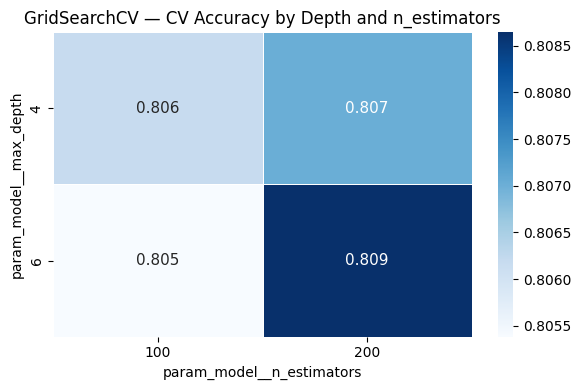

In [7]:
# CV results as a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(
    index='param_model__max_depth',
    columns='param_model__n_estimators',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('GridSearchCV — CV Accuracy by Depth and n_estimators')
plt.tight_layout()
plt.show()

**Observation:**
GridSearchCV tunes preprocessing and model hyperparameters jointly without any data leakage across folds. The heatmap shows how `max_depth` and `n_estimators` interact — this pattern is used again in the Week 7 Spaceship Titanic tuning notebook.

## Pipeline Inspection

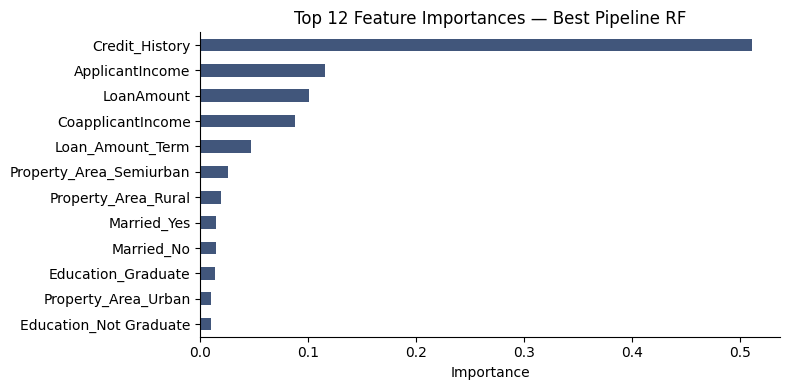

In [8]:
best_pipe = grid_search.best_estimator_

# Feature names after ColumnTransformer
ohe_cats = best_pipe.named_steps['preprocessor'] \
           .named_transformers_['cat']['ohe'] \
           .get_feature_names_out(cat_cols)
all_features = num_cols + list(ohe_cats)

importances = best_pipe.named_steps['model'].feature_importances_
imp_df = pd.Series(importances, index=all_features).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 4))
imp_df[::-1].plot(kind='barh', color='#1F3864', alpha=0.85, ax=ax)
ax.set_title('Top 12 Feature Importances — Best Pipeline RF')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Observation:**
`Credit_History` dominates feature importances even after the full preprocessing pipeline — consistent with its coefficient magnitude in the Logistic Regression from Week 4. Inspecting the pipeline's fitted components after GridSearchCV is the standard workflow used in every subsequent Week 7 model notebook.